In [2]:
# adding the project directory to system path
import os
import sys

sys.path.append(os.path.abspath('..'))

In [76]:
from src.data_loader import Load_Data
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import pandas as pd
import matplotx as mpx
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict

In [4]:
df = Load_Data()
df

,SampleID,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000,PRAD
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000,BRCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,sample_796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,...,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000,BRCA
797,sample_797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,...,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000,LUAD
798,sample_798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,...,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693,COAD
799,sample_799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,...,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000,PRAD


In [5]:
X = df.drop(['Class','SampleID'],axis = 1)
Y = df['Class']
X

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,0.0,...,6.088133,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000
797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,0.0,...,6.371876,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000
798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,0.0,...,5.719386,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693
799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,0.0,...,5.785237,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000


In [6]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [7]:
param_grid = {'n_estimators': [100,200,300],
             'max_depth': [None,2,5,10]}

grid = GridSearchCV(RandomForestClassifier(),param_grid,cv = 5)
grid.fit(x_train,y_train)

grid.best_params_

{'max_depth': 5, 'n_estimators': 100}

In [8]:
Rf_model = grid.best_estimator_
y_pred = Rf_model.predict(x_test)
y_pred

array(['LUAD', 'BRCA', 'LUAD', 'KIRC', 'BRCA', 'BRCA', 'BRCA', 'COAD',
       'PRAD', 'LUAD', 'COAD', 'BRCA', 'LUAD', 'PRAD', 'KIRC', 'LUAD',
       'LUAD', 'PRAD', 'BRCA', 'LUAD', 'LUAD', 'COAD', 'KIRC', 'BRCA',
       'BRCA', 'BRCA', 'COAD', 'BRCA', 'PRAD', 'PRAD', 'BRCA', 'PRAD',
       'PRAD', 'COAD', 'BRCA', 'BRCA', 'LUAD', 'BRCA', 'LUAD', 'BRCA',
       'COAD', 'BRCA', 'BRCA', 'BRCA', 'KIRC', 'PRAD', 'KIRC', 'COAD',
       'BRCA', 'BRCA', 'PRAD', 'LUAD', 'KIRC', 'BRCA', 'KIRC', 'BRCA',
       'KIRC', 'BRCA', 'LUAD', 'LUAD', 'LUAD', 'KIRC', 'PRAD', 'BRCA',
       'PRAD', 'BRCA', 'LUAD', 'PRAD', 'KIRC', 'BRCA', 'BRCA', 'LUAD',
       'BRCA', 'BRCA', 'BRCA', 'LUAD', 'PRAD', 'PRAD', 'KIRC', 'BRCA',
       'KIRC', 'BRCA', 'BRCA', 'KIRC', 'LUAD', 'BRCA', 'BRCA', 'PRAD',
       'COAD', 'COAD', 'COAD', 'KIRC', 'BRCA', 'BRCA', 'BRCA', 'PRAD',
       'LUAD', 'COAD', 'COAD', 'BRCA', 'BRCA', 'BRCA', 'BRCA', 'LUAD',
       'BRCA', 'KIRC', 'BRCA', 'KIRC', 'BRCA', 'BRCA', 'PRAD', 'KIRC',
      

In [12]:
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
scores = cross_validate(Rf_model, X, Y, cv=5, scoring=scoring)
y_pred_cv = cross_val_predict(Rf_model, X, Y, cv=5)

In [14]:
print('Random Forest Classifier Results:')
print("Accuracy:", scores['test_accuracy'].mean())
print("Precision:", scores['test_precision_weighted'].mean())
print("Recall:", scores['test_recall_weighted'].mean())
print("F1 Score:", scores['test_f1_weighted'].mean())
print('Classification Report:\n', classification_report(Y, y_pred_cv))
print('Confusion Matrix:\n', confusion_matrix(Y, y_pred_cv))

Random Forest Classifier Results:
Accuracy: 0.9937655279503106
Precision: 0.9939694208195441
Recall: 0.9937655279503106
F1 Score: 0.9937287017422417
Classification Report:
               precision    recall  f1-score   support

        BRCA       0.99      1.00      1.00       300
        COAD       1.00      1.00      1.00        78
        KIRC       1.00      0.99      1.00       146
        LUAD       1.00      0.99      0.99       141
        PRAD       1.00      1.00      1.00       136

    accuracy                           1.00       801
   macro avg       1.00      1.00      1.00       801
weighted avg       1.00      1.00      1.00       801

Confusion Matrix:
 [[300   0   0   0   0]
 [  0  78   0   0   0]
 [  1   0 145   0   0]
 [  2   0   0 139   0]
 [  0   0   0   0 136]]


In [24]:
feat_imp = pd.Series(Rf_model.feature_importances_, index=X.columns)
print(feat_imp.nlargest(50))

gene_5407     0.014964
gene_6876     0.009808
gene_16358    0.009102
gene_8598     0.008296
gene_18746    0.008289
gene_6828     0.008253
gene_8009     0.007859
gene_12808    0.007847
gene_4210     0.007712
gene_15301    0.007686
gene_7964     0.007544
gene_18391    0.007485
gene_1510     0.007180
gene_5027     0.006607
gene_18381    0.006495
gene_15633    0.006422
gene_5729     0.006042
gene_7896     0.005777
gene_221      0.005710
gene_8003     0.005707
gene_14190    0.005519
gene_12983    0.005478
gene_15987    0.005443
gene_17993    0.005268
gene_15899    0.005239
gene_15473    0.005045
gene_5021     0.005028
gene_16342    0.004973
gene_15736    0.004928
gene_13818    0.004914
gene_17317    0.004886
gene_6355     0.004854
gene_14467    0.004827
gene_1509     0.004812
gene_380      0.004810
gene_8004     0.004488
gene_17166    0.004465
gene_1923     0.004359
gene_5577     0.004354
gene_5598     0.004308
gene_7421     0.004255
gene_753      0.004091
gene_11259    0.004024
gene_8014  

In [59]:
top_features = feat_imp.nlargest(5).index

X_top = X[top_features]

In [60]:
scores = cross_val_score(Rf_model, X_top, Y, cv=5)
print(scores.mean())

0.9188509316770187


In [68]:
selector = VarianceThreshold(threshold=0)

X_clean = selector.fit_transform(X)

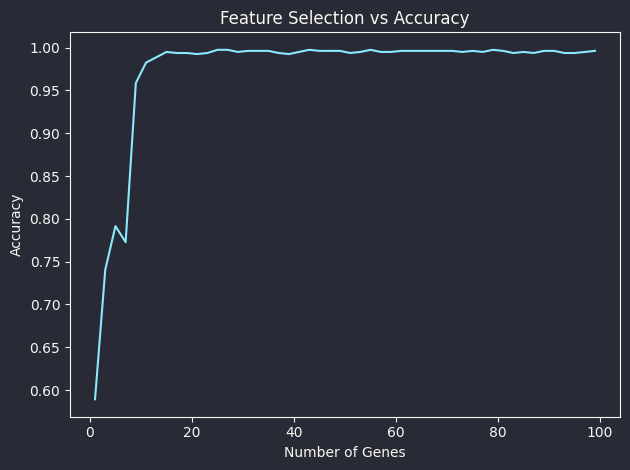

In [78]:
k_values = [x for x in range(1,101,2)]
scores = []

for k in k_values:
    selector = SelectKBest(f_classif, k=k)
    X_new = selector.fit_transform(X_clean, Y)
    score = cross_val_score(Rf_model, X_new, Y, cv=5).mean()
    scores.append(score)

with plt.style.context(mpx.styles.dracula):
    plt.plot(k_values, scores)
    plt.xlabel("Number of Genes")
    plt.ylabel("Accuracy")
    plt.title("Feature Selection vs Accuracy")
    plt.tight_layout()
    plt.savefig("feature_vs_accuracy.png", dpi=300)
    plt.show()